# Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Arsenal team-players 2025_2026.xlsx to Arsenal team-players 2025_2026.xlsx


In [3]:
df = pd.read_excel('Arsenal team-players 2025_2026.xlsx')

In [4]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   number    24 non-null     int64  
 1   player    24 non-null     object 
 2   position  24 non-null     object 
 3   apps      24 non-null     int64  
 4   min       24 non-null     int64  
 5   goals     24 non-null     int64  
 6   assists   24 non-null     int64  
 7   sp90m     24 non-null     float64
 8   kp90      24 non-null     float64
 9   xG        24 non-null     float64
 10  xA        24 non-null     float64
 11  xG90      24 non-null     float64
 12  xA90      24 non-null     float64
dtypes: float64(6), int64(5), object(2)
memory usage: 2.6+ KB


,number,player,position,apps,min,goals,assists,sp90m,kp90,xG,xA,xG90,xA90
0,1,Viktor Gyokeres,F,32,2079,12,0,2.08,0.74,11.43,2.21,0.49,0.10
1,2,Eberechi Eze,F M,28,1602,7,2,2.64,0.79,3.84,2.14,0.22,0.12
2,3,Bukayo Saka,F M,28,2016,6,3,2.86,2.41,8.31,6.43,0.37,0.29
3,4,Martín Zubimendi,M,34,2884,5,1,0.84,0.53,2.94,0.89,0.09,0.03
4,5,Leandro Trossard,F M,28,1756,5,5,2.26,1.64,5.79,3.88,0.30,0.20


# Basic Player Info
# number
Player’s shirt number
👉 No analytical value, just identification
# player
Player name
👉 Used for labeling, grouping, reporting
# position
Player role (e.g., Forward, Midfielder, Defender)

👉 Important for:

Comparing players fairly
Group-level analysis (attack vs midfield vs defense)
# Playing Time
apps (Appearances)
Number of matches played

👉 Limitation:

Doesn’t show how long they played
# min (Minutes Played)
Total minutes on the pitch

👉 VERY IMPORTANT:

This is what makes per 90 stats possible
⚽ Output Metrics (What actually happened)
# goals
Total goals scored

👉 Key for:

Measuring finishing output
# assists
Final pass leading to a goal

👉 Measures:

Direct creativity
📈 Advanced Performance Metrics
# sp90m (Shots per 90 minutes)
Average shots a player takes every 90 minutes

👉 Tells you:

How often a player shoots
Aggressiveness in attack

Example:

High sp90m = striker mentality
Low sp90m = deeper role
# kp90 (Key passes per 90)
Passes that lead to a shot (not necessarily a goal)

👉 Tells you:

Creative involvement

Important:

Better than assists because it removes luck
🎯 Expected Metrics (VERY IMPORTANT)

These are what make your project elite-level

# xG (Expected Goals)

→ A measure from Football Analytics

Probability that a shot becomes a goal
Based on:
Shot location
Angle
Type of chance

👉 Example:

Tap-in → high xG (0.7+)
Long shot → low xG (0.02)
# xA (Expected Assists)
Measures the quality of chances a player creates

👉 Instead of:

“Did it become a goal?”
It asks:
“Should it have become a goal?”
⚡ Per 90 Metrics (Fair Comparison)

These normalize performance based on minutes.

# xG90
Expected goals per 90 minutes

👉 Tells you:

How dangerous a player is if they played a full match
# xA90
Expected assists per 90 minutes

👉 Tells you:

Creative output per full game

# STEP 1 (CORE ANALYSIS)
Who are the most efficient attackers at Arsenal FC?

# Step 1A: Define “Efficiency” Properly

Efficiency ≠ just goals.

We measure 3 things:

1. Finishing Efficiency

How well a player converts chances

Finishing Efficiency=
xG
Goals
	​

2. Creativity Efficiency

How well chances created turn into assists

Creativity Efficiency=
xA
Assists


3. Overall Threat

Total attacking impact

Threat Score=xG90+xA90


# Build These Metrics

In [5]:
# Per 90 output
df["goals90"] = df["goals"] / df["min"] * 90
df["assists90"] = df["assists"] / df["min"] * 90

# Efficiency (safe division)
df["finishing_efficiency"] = np.where(df["xG"] > 0, df["goals"] / df["xG"], 0)
df["creativity_efficiency"] = np.where(df["xA"] > 0, df["assists"] / df["xA"], 0)

# Overall attacking impact
df["threat_score"] = df["xG90"] + df["xA90"]

# Find the Key Players
🔥 1. Most Dangerous Players

In [6]:
df.sort_values("threat_score", ascending=False)[
    ["player", "position", "threat_score", "xG90", "xA90"]
].head(10)

,player,position,threat_score,xG90,xA90
17,Max Dowman,S,0.93,0.71,0.22
9,Gabriel Jesus,F,0.88,0.83,0.05
11,Kai Havertz,F M,0.78,0.73,0.05
2,Bukayo Saka,F M,0.66,0.37,0.29
13,Gabriel Martinelli,F M,0.66,0.47,0.19
5,Mikel Merino,F M,0.63,0.42,0.21
0,Viktor Gyokeres,F,0.59,0.49,0.10
4,Leandro Trossard,F M,0.50,0.30,0.20
10,Martin Odegaard,M,0.43,0.08,0.35
16,Noni Madueke,F M,0.37,0.15,0.22


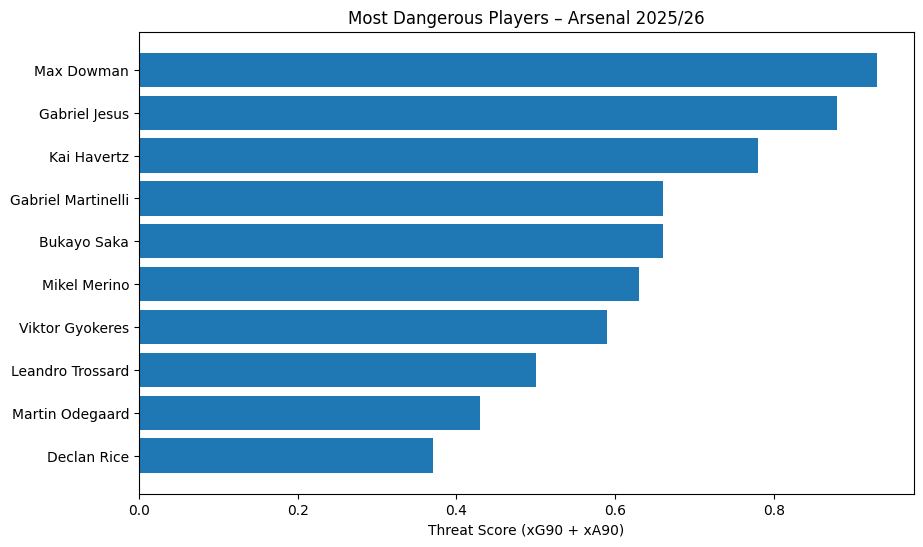

In [7]:
import matplotlib.pyplot as plt

# Sort data
top_players = df.sort_values("threat_score", ascending=True).tail(10)

plt.figure(figsize=(10,6))

plt.barh(top_players["player"], top_players["threat_score"])

plt.xlabel("Threat Score (xG90 + xA90)")
plt.title("Most Dangerous Players – Arsenal 2025/26")

plt.show()

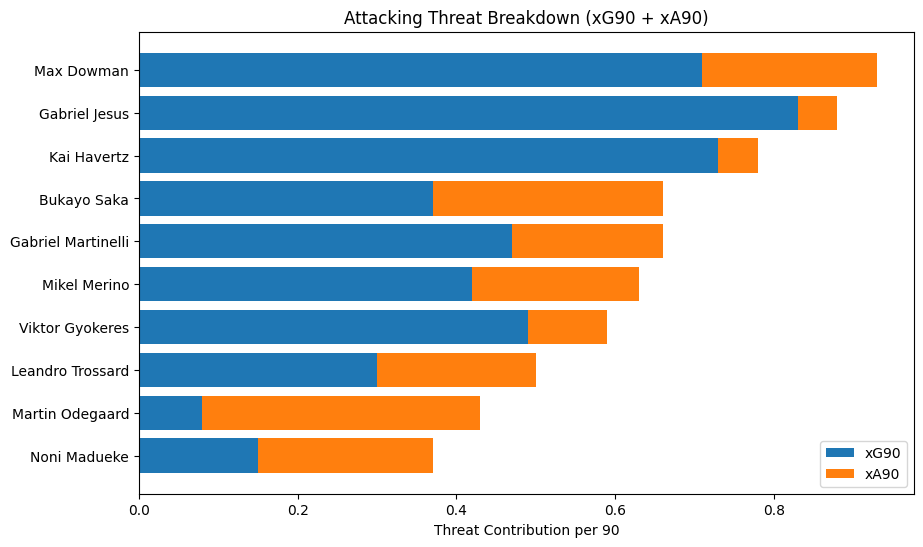

In [8]:
import matplotlib.pyplot as plt

top_players = df.sort_values("threat_score", ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top_players["player"], top_players["xG90"], label="xG90")
plt.barh(top_players["player"], top_players["xA90"], left=top_players["xG90"], label="xA90")

plt.xlabel("Threat Contribution per 90")
plt.title("Attacking Threat Breakdown (xG90 + xA90)")
plt.legend()

plt.gca().invert_yaxis()

plt.show()

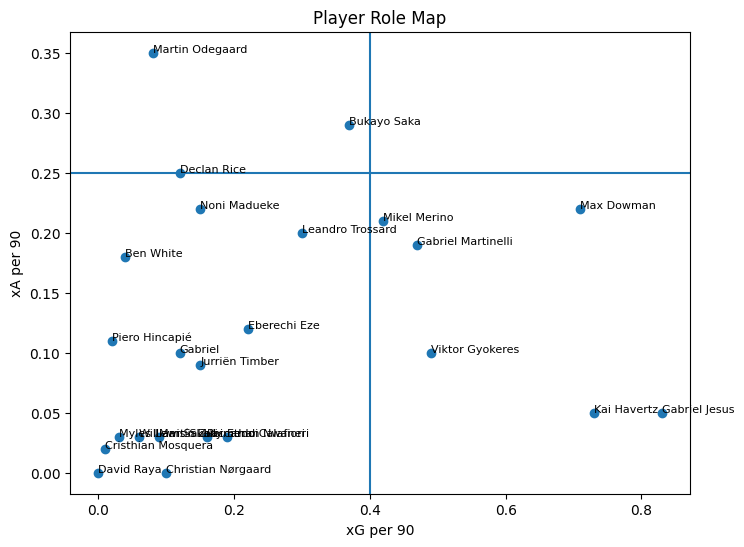

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["xG90"], df["xA90"])

for i in range(len(df)):
    plt.text(df["xG90"][i], df["xA90"][i], df["player"][i], fontsize=8)

plt.xlabel("xG per 90")
plt.ylabel("xA per 90")
plt.title("Player Role Map")

plt.axvline(0.4)
plt.axhline(0.25)

plt.show()

# Best Finishers

In [10]:
df.sort_values("finishing_efficiency", ascending=False)[
    ["player", "goals", "xG", "finishing_efficiency"]
].head(10)

,player,goals,xG,finishing_efficiency
15,Piero Hincapié,1,0.40,2.500000
17,Max Dowman,1,0.54,1.851852
1,Eberechi Eze,7,3.84,1.822917
3,Martín Zubimendi,5,2.94,1.700680
6,Declan Rice,4,3.72,1.075269
0,Viktor Gyokeres,12,11.43,1.049869
7,Gabriel,3,3.36,0.892857
10,Martin Odegaard,1,1.12,0.892857
5,Mikel Merino,4,4.55,0.879121
4,Leandro Trossard,5,5.79,0.863558


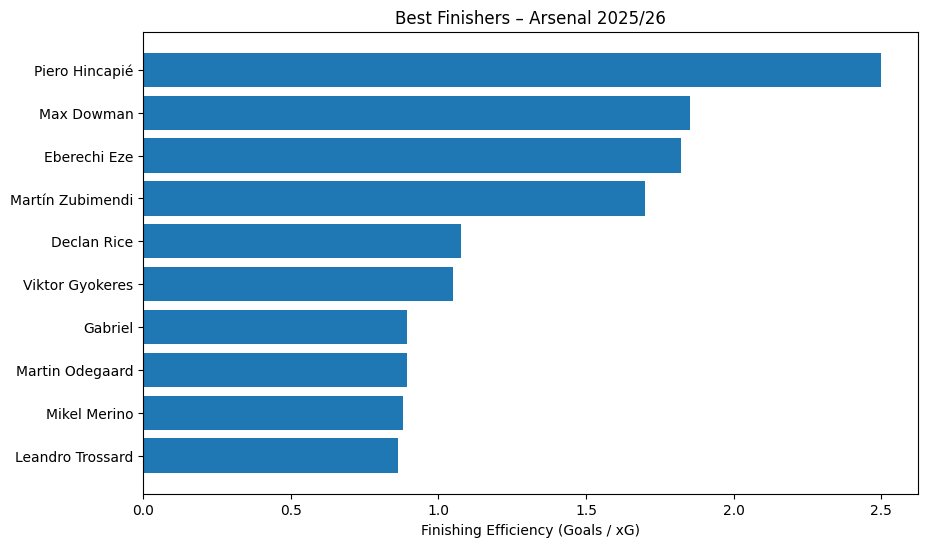

In [11]:
import matplotlib.pyplot as plt

# Sort and select top finishers
top_finishers = df.sort_values("finishing_efficiency", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_finishers["player"], top_finishers["finishing_efficiency"])

plt.xlabel("Finishing Efficiency (Goals / xG)")
plt.title("Best Finishers – Arsenal 2025/26")

plt.gca().invert_yaxis()
plt.show()

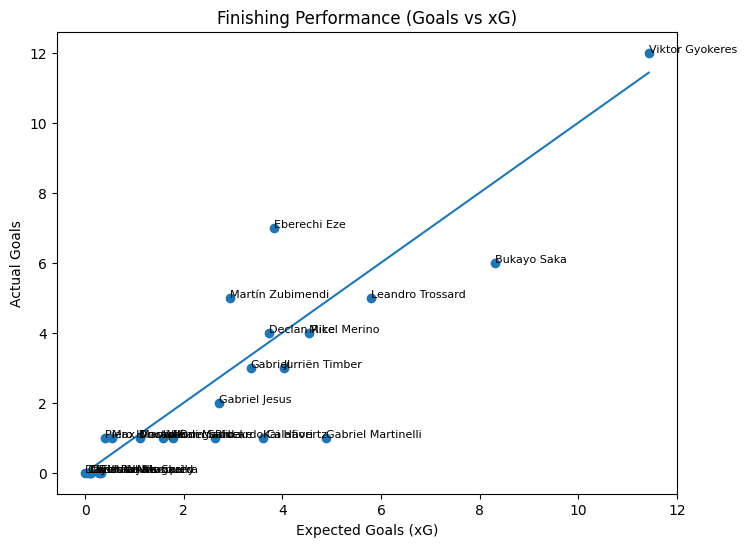

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["xG"], df["goals"])

# Add player names
for i in range(len(df)):
    plt.text(df["xG"][i], df["goals"][i], df["player"][i], fontsize=8)

# Perfect finishing line
plt.plot([0, df["xG"].max()], [0, df["xG"].max()])

plt.xlabel("Expected Goals (xG)")
plt.ylabel("Actual Goals")
plt.title("Finishing Performance (Goals vs xG)")

plt.show()

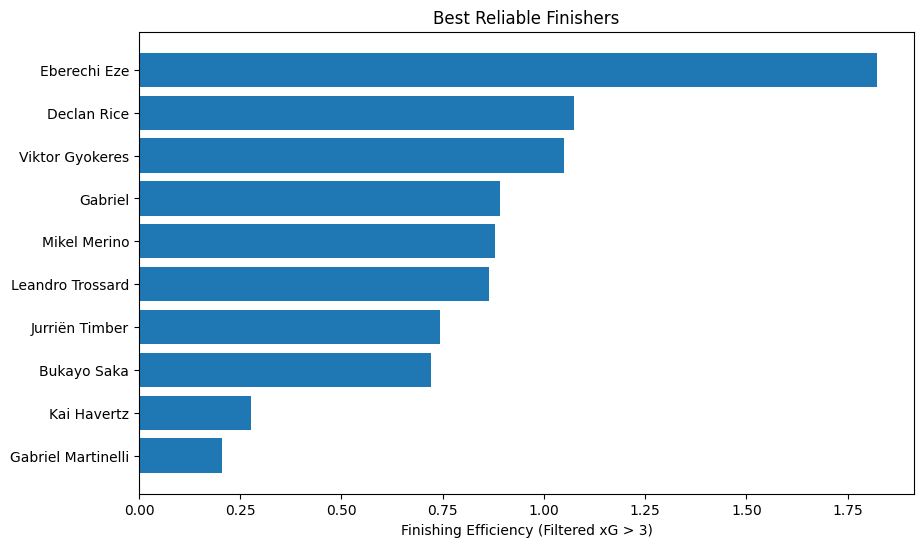

In [13]:
# Filter players with meaningful xG
filtered = df[df["xG"] > 3]

top_finishers = filtered.sort_values("finishing_efficiency", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(top_finishers["player"], top_finishers["finishing_efficiency"])

plt.xlabel("Finishing Efficiency (Filtered xG > 3)")
plt.title("Best Reliable Finishers")

plt.gca().invert_yaxis()
plt.show()

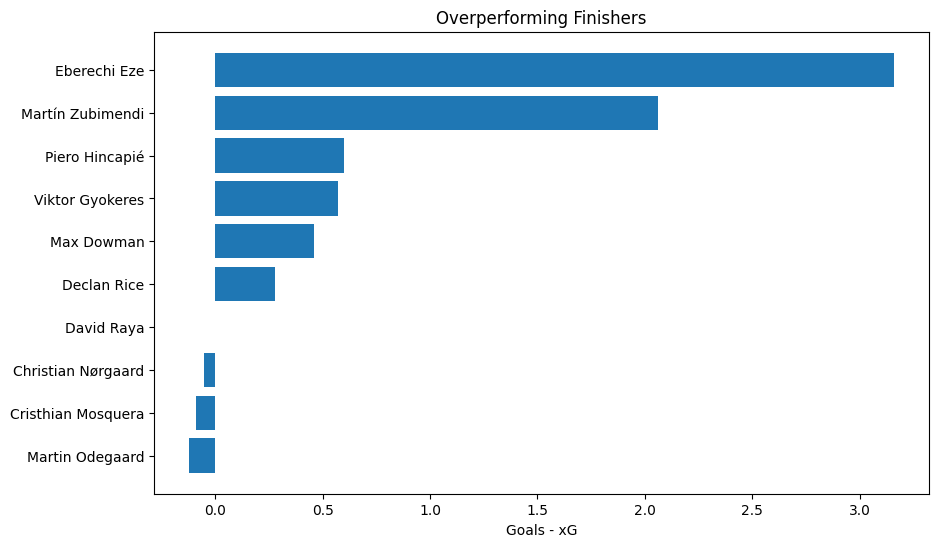

In [14]:
df["finishing_diff"] = df["goals"] - df["xG"]

top_diff = df.sort_values("finishing_diff", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_diff["player"], top_diff["finishing_diff"])

plt.xlabel("Goals - xG")
plt.title("Overperforming Finishers")

plt.gca().invert_yaxis()
plt.show()

# Best Creators

In [15]:
df.sort_values("creativity_efficiency", ascending=False)[
    ["player", "assists", "xA", "creativity_efficiency", "kp90"]
].head(10)

,player,assists,xA,creativity_efficiency,kp90
11,Kai Havertz,2,0.23,8.695652,1.01
14,Riccardo Calafiori,2,0.45,4.444444,0.30
8,Jurriën Timber,5,2.59,1.930502,1.02
13,Gabriel Martinelli,3,1.98,1.515152,1.06
7,Gabriel,4,2.73,1.465201,0.26
5,Mikel Merino,3,2.29,1.310044,1.11
4,Leandro Trossard,5,3.88,1.288660,1.64
3,Martín Zubimendi,1,0.89,1.123596,0.53
10,Martin Odegaard,5,4.81,1.039501,2.62
15,Piero Hincapié,2,2.13,0.938967,0.70


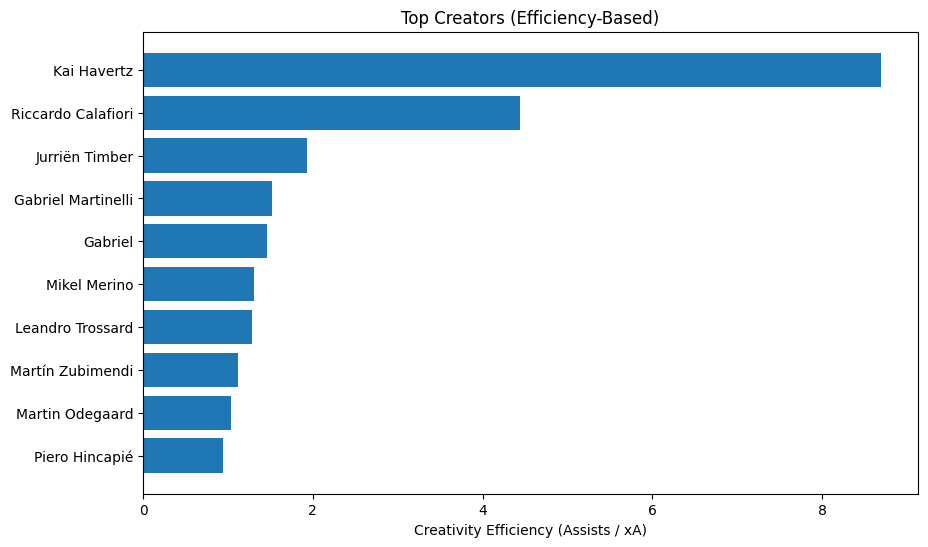

In [16]:
import matplotlib.pyplot as plt

top_creators = df.sort_values("creativity_efficiency", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_creators["player"], top_creators["creativity_efficiency"])

plt.xlabel("Creativity Efficiency (Assists / xA)")
plt.title("Top Creators (Efficiency-Based)")

plt.gca().invert_yaxis()
plt.show()

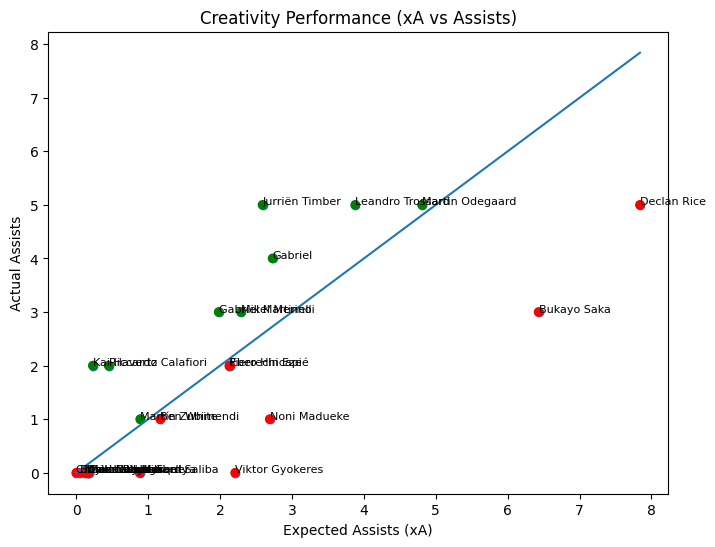

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["xA"], df["assists"])

colors = []

for i in range(len(df)):
    if df["assists"][i] > df["xA"][i]:
        colors.append("green")  # overperforming
    else:
        colors.append("red")    # underperforming

plt.scatter(df["xA"], df["assists"], c=colors)

# Add player labels
for i in range(len(df)):
    plt.text(df["xA"][i], df["assists"][i], df["player"][i], fontsize=8)

# Perfect line
plt.plot([0, df["xA"].max()], [0, df["xA"].max()])

plt.xlabel("Expected Assists (xA)")
plt.ylabel("Actual Assists")
plt.title("Creativity Performance (xA vs Assists)")

plt.show()

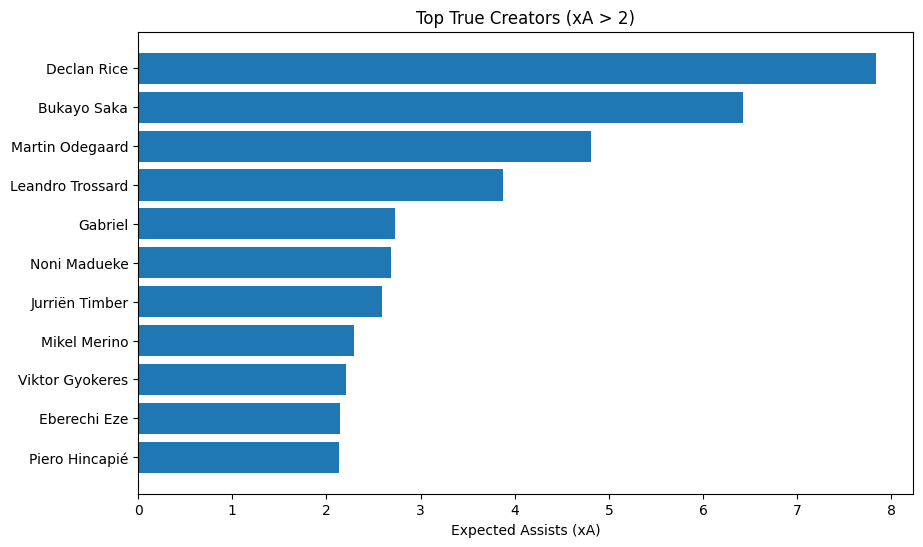

In [18]:
filtered = df[df["xA"] > 2]

top_creators = filtered.sort_values("xA", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(top_creators["player"], top_creators["xA"])

plt.xlabel("Expected Assists (xA)")
plt.title("Top True Creators (xA > 2)")

plt.gca().invert_yaxis()
plt.show()

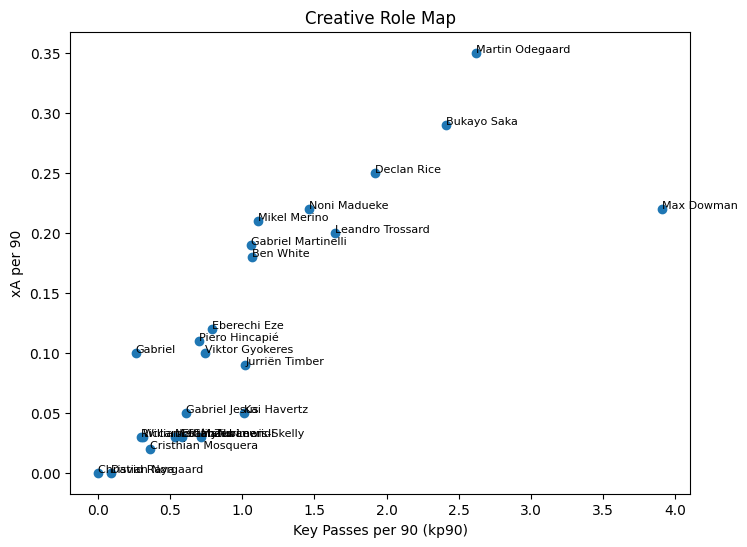

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(df["kp90"], df["xA90"])

for i in range(len(df)):
    plt.text(df["kp90"][i], df["xA90"][i], df["player"][i], fontsize=8)

plt.xlabel("Key Passes per 90 (kp90)")
plt.ylabel("xA per 90")
plt.title("Creative Role Map")

plt.show()

In [20]:
df_filtered = df[df["xA"] > 2]

In [21]:
df_filtered.head()

,number,player,position,apps,min,goals,assists,sp90m,kp90,xG,xA,xG90,xA90,goals90,assists90,finishing_efficiency,creativity_efficiency,threat_score,finishing_diff
0,1,Viktor Gyokeres,F,32,2079,12,0,2.08,0.74,11.43,2.21,0.49,0.10,0.519481,0.000000,1.049869,0.000000,0.59,0.57
1,2,Eberechi Eze,F M,28,1602,7,2,2.64,0.79,3.84,2.14,0.22,0.12,0.393258,0.112360,1.822917,0.934579,0.34,3.16
2,3,Bukayo Saka,F M,28,2016,6,3,2.86,2.41,8.31,6.43,0.37,0.29,0.267857,0.133929,0.722022,0.466563,0.66,-2.31
4,5,Leandro Trossard,F M,28,1756,5,5,2.26,1.64,5.79,3.88,0.30,0.20,0.256264,0.256264,0.863558,1.288660,0.50,-0.79
5,6,Mikel Merino,F M,21,977,4,3,1.93,1.11,4.55,2.29,0.42,0.21,0.368475,0.276356,0.879121,1.310044,0.63,-0.55


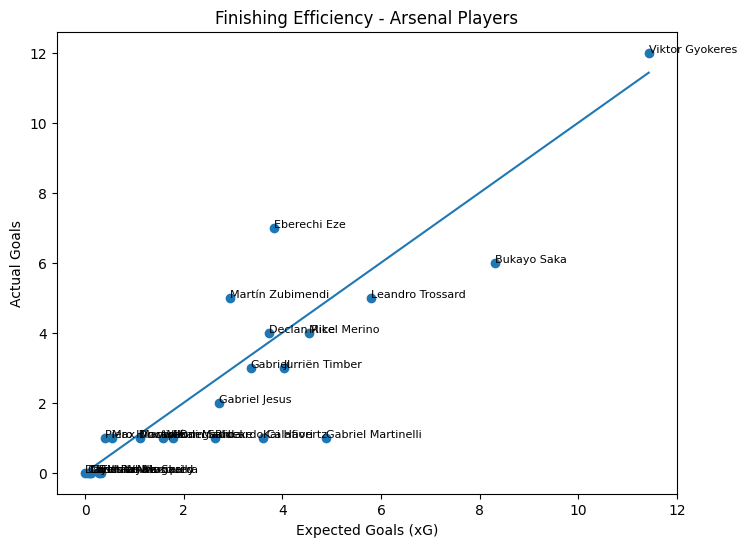

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["xG"], df["goals"])

# Label players
for i in range(len(df)):
    plt.text(df["xG"][i], df["goals"][i], df["player"][i], fontsize=8)

# Perfect finishing line
plt.plot([0, df["xG"].max()], [0, df["xG"].max()])

plt.xlabel("Expected Goals (xG)")
plt.ylabel("Actual Goals")
plt.title("Finishing Efficiency - Arsenal Players")
plt.show()